In [9]:
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer


In [10]:
# 2. LOAD DATASET
# ========================
df = pd.read_csv("C:\\Users\\Admin\\Downloads\\OBSIP\\Triveni_Task2\\Dataset\\customer_segmentation_data.csv")

In [11]:
# 3. DATA EXPLORATION
# =========================

print("========== FIRST 5 ROWS ==========")
print(df.head())

print("\n========== DATASET INFO ==========")
print(df.info())

print("\n========== NULL VALUES ==========")
print(df.isnull().sum())

print("\n========== DESCRIPTIVE STATISTICS ==========")
print(df.describe())

========== FIRST 5 ROWS ==========
   id  age  gender  income  spending_score  membership_years  \
0   1   38  Female   99342              90                 3   
1   2   21  Female   78852              60                 2   
2   3   60  Female  126573              30                 2   
3   4   40   Other   47099              74                 9   
4   5   65  Female  140621              21                 3   

   purchase_frequency preferred_category  last_purchase_amount  
0                  24          Groceries                113.53  
1                  42             Sports                 41.93  
2                  28           Clothing                424.36  
3                   5      Home & Garden                991.93  
4                  25        Electronics                347.08  

========== DATASET INFO ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype 

In [12]:

# =========================
# 4. DATA CLEANING
# =========================

# Select only numeric columns
numeric_columns = df.select_dtypes(include=np.number).columns

# Fill missing numeric values with mean
imputer = SimpleImputer(strategy='mean')
df[numeric_columns] = imputer.fit_transform(df[numeric_columns])

print("\n========== AFTER CLEANING ==========")
print(df.isnull().sum())



========== AFTER CLEANING ==========
id                      0
age                     0
gender                  0
income                  0
spending_score          0
membership_years        0
purchase_frequency      0
preferred_category      0
last_purchase_amount    0
dtype: int64


In [13]:
# 5. DESCRIPTIVE STATISTICS
# =========================

print("\n========== BUSINESS METRICS ==========")

# Example metrics
for col in numeric_columns:
    print(f"\nColumn: {col}")
    print("Average :", df[col].mean())
    print("Minimum :", df[col].min())
    print("Maximum :", df[col].max())
    print("Standard Deviation :", df[col].std())


========== BUSINESS METRICS ==========

Column: id
Average : 500.5
Minimum : 1.0
Maximum : 1000.0
Standard Deviation : 288.8194360957494

Column: age
Average : 43.783
Minimum : 18.0
Maximum : 69.0
Standard Deviation : 15.042213240716235

Column: income
Average : 88500.8
Minimum : 30004.0
Maximum : 149973.0
Standard Deviation : 34230.771122480364

Column: spending_score
Average : 50.685
Minimum : 1.0
Maximum : 100.0
Standard Deviation : 28.95517530903893

Column: membership_years
Average : 5.469
Minimum : 1.0
Maximum : 10.0
Standard Deviation : 2.855730063257764

Column: purchase_frequency
Average : 26.596
Minimum : 1.0
Maximum : 50.0
Standard Deviation : 14.24365352238203

Column: last_purchase_amount
Average : 492.34867
Minimum : 10.4
Maximum : 999.74
Standard Deviation : 295.7442525647049


In [14]:
# 6. FEATURE SELECTION
# =========================

# Using numeric data for clustering
X = df[numeric_columns]


In [15]:
# =========================
# 7. FEATURE SCALING
# =========================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

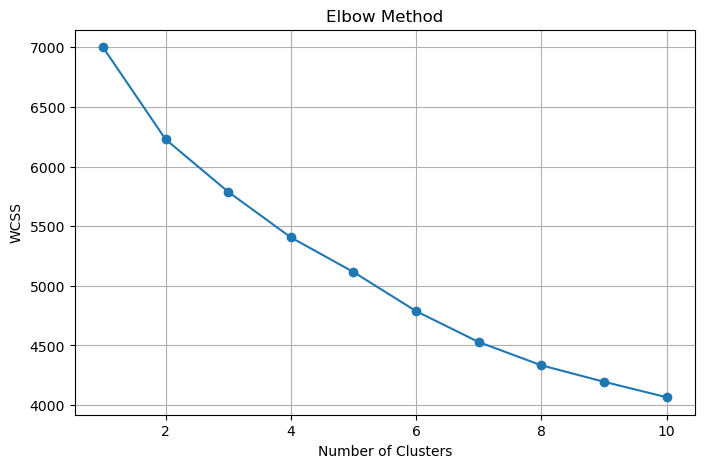

In [16]:
# 8. FIND OPTIMAL K (ELBOW METHOD)
# =========================

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Graph
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

In [17]:
# 9. APPLY K-MEANS CLUSTERING
# =========================

# Choose cluster count based on elbow graph
k = 4

kmeans = KMeans(n_clusters=k, random_state=42)

df['Cluster'] = kmeans.fit_predict(X_scaled)

print("\n========== CLUSTER COUNTS ==========")
print(df['Cluster'].value_counts())


========== CLUSTER COUNTS ==========
Cluster
2    261
3    258
0    247
1    234
Name: count, dtype: int64


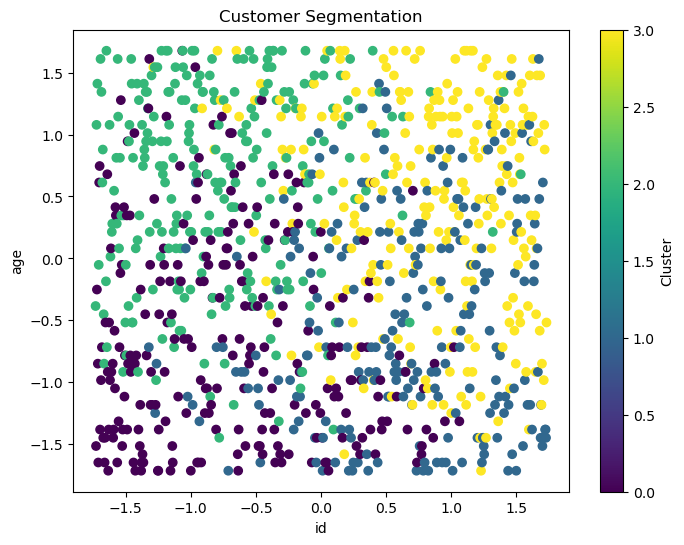

In [18]:
# 10. VISUALIZATION
# =========================

# Scatter Plot using first 2 numeric columns
plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=df['Cluster'],
    cmap='viridis'
)

plt.title("Customer Segmentation")
plt.xlabel(numeric_columns[0])
plt.ylabel(numeric_columns[1])

plt.colorbar(label='Cluster')
plt.show()


In [19]:
# 11. SEGMENT ANALYSIS
# =========================

print("\n========== CLUSTER ANALYSIS ==========")

cluster_analysis = df.groupby('Cluster')[numeric_columns].mean()

print(cluster_analysis)


========== CLUSTER ANALYSIS ==========
                 id        age         income  spending_score  \
Cluster                                                         
0        299.688259  34.113360   69437.481781       35.995951   
1        691.423077  36.474359  110093.222222       50.487179   
2        282.517241  52.724138  108170.471264       63.187739   
3        740.104651  50.624031   67269.127907       52.279070   

         membership_years  purchase_frequency  last_purchase_amount  
Cluster                                                              
0                4.862348           27.121457            488.452955  
1                6.773504           36.337607            520.779744  
2                5.482759           24.513410            428.827663  
3                4.852713           19.364341            534.551589  


In [20]:
# 12. INSIGHTS & RECOMMENDATIONS
# =========================

print("\n========== INSIGHTS ==========")

for cluster in cluster_analysis.index:

    print(f"\nCluster {cluster}")

    print(cluster_analysis.loc[cluster])

    print("\nRecommendation:")

    print("- Analyze customer behavior")
    print("- Provide personalized offers")
    print("- Improve retention strategies")
    print("- Target high-value customers with premium plans")


========== INSIGHTS ==========

Cluster 0
id                        299.688259
age                        34.113360
income                  69437.481781
spending_score             35.995951
membership_years            4.862348
purchase_frequency         27.121457
last_purchase_amount      488.452955
Name: 0, dtype: float64

Recommendation:
- Analyze customer behavior
- Provide personalized offers
- Improve retention strategies
- Target high-value customers with premium plans

Cluster 1
id                         691.423077
age                         36.474359
income                  110093.222222
spending_score              50.487179
membership_years             6.773504
purchase_frequency          36.337607
last_purchase_amount       520.779744
Name: 1, dtype: float64

Recommendation:
- Analyze customer behavior
- Provide personalized offers
- Improve retention strategies
- Target high-value customers with premium plans

Cluster 2
id                         282.517241
age           

In [21]:
# 13. SAVE OUTPUT
# =========================

df.to_csv("customer_segmented_output.csv", index=False)

print("\nSegmented dataset saved successfully!")


Segmented dataset saved successfully!
